# CICIDS2017 Intrusion Detection - Data Preprocessing & ML Models

### Steps covered:

* Load and merge CICIDS2017 CSV files
* Handle missing and infinite values
* Encode labels

  * Binary: Normal vs Attack
  * Multi-class: Specific attack categories
* Normalize features using StandardScaler
* Split into train & test sets
* Train ML models (Random Forest, Logistic Regression, XGBoost, etc.)
* Evaluate performance with Accuracy, Precision, Recall, F1-score, and Confusion Matrix


## Step 1: Load CICIDS2017 Friday CSV File

The CICIDS2017 dataset is divided into multiple daily CSV files.
For this workflow, we will use only the **Friday dataset**, which contains normal and attack traffic.
We load it into a DataFrame for further preprocessing.


In [2]:

import pandas as pd

# Path to Friday CSV file
file_path = "D:\SpringBoard\CICID\Wednesday-workingHours.pcap_ISCX.csv"

# Load dataset
cicids_df = pd.read_csv(file_path, low_memory=False)

print("Dataset shape:", cicids_df.shape)
print("Columns:", cicids_df.columns[:])  # show first 10 columns



Dataset shape: (692703, 79)
Columns: Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Leng


## Step 2: Handle Missing and Infinite Values

The CICIDS2017 dataset may contain:

* Missing values (`NaN`)
* Infinite values (`inf` or `-inf`)

These need to be handled before training ML models to avoid errors.

Common strategies:

* Replace infinite values with `NaN`
* Fill `NaN` values with column median (or mean)
* Ensure numeric columns are in a suitable type (`float32`) to save memory


In [3]:

import numpy as np

# Replace infinite values with NaN
cicids_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with column median safely (no chained assignment)
numeric_cols = cicids_df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    median_val = cicids_df[col].median()
    cicids_df[col] = cicids_df[col].fillna(median_val)  # assign back to avoid FutureWarning
    cicids_df[col] = cicids_df[col].astype(np.float32)  # reduce memory

# Check remaining NaN values
print("Remaining NaN values per column:\n", cicids_df.isna().sum().head(10))


Remaining NaN values per column:
  Destination Port               0
 Flow Duration                  0
 Total Fwd Packets              0
 Total Backward Packets         0
Total Length of Fwd Packets     0
 Total Length of Bwd Packets    0
 Fwd Packet Length Max          0
 Fwd Packet Length Min          0
 Fwd Packet Length Mean         0
 Fwd Packet Length Std          0
dtype: int64


## Step 3: Encode Labels

The `Label` column in CICIDS2017 contains the type of traffic:

* `"BENIGN"` indicates normal traffic
* Other values indicate different types of attacks (DoS, DDoS, PortScan, etc.)

We need to encode the labels numerically for ML models:

1. **Binary classification**:

   * Normal (`BENIGN`) → 0
   * Attack (all others) → 1

2. **Multi-class classification**:

   * Each attack type receives a unique integer


In [4]:

from sklearn.preprocessing import LabelEncoder

# Strip column names to remove leading/trailing spaces
cicids_df.columns = cicids_df.columns.str.strip()

# Strip whitespace from Label column values
cicids_df['Label'] = cicids_df['Label'].str.strip()

# Binary classification: Normal vs Attack
cicids_df['BinaryLabel'] = cicids_df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Multi-class classification: each attack type gets a unique integer
le = LabelEncoder()
cicids_df['MultiClassLabel'] = le.fit_transform(cicids_df['Label'])

# Check counts
print("Binary label distribution:\n", cicids_df['BinaryLabel'].value_counts())
print("\nMulti-class label distribution:\n", cicids_df['MultiClassLabel'].value_counts().head(10))


Binary label distribution:
 BinaryLabel
0    440031
1    252672
Name: count, dtype: int64

Multi-class label distribution:
 MultiClassLabel
0    440031
2    231073
1     10293
4      5796
3      5499
5        11
Name: count, dtype: int64


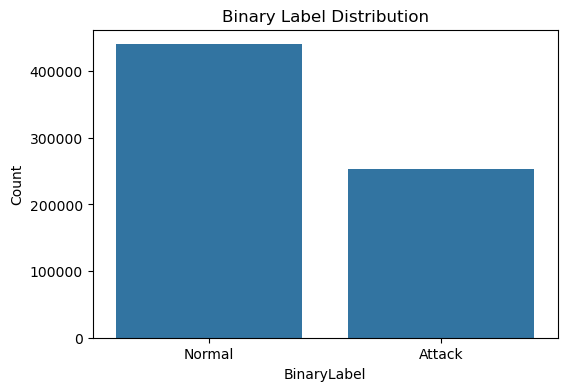

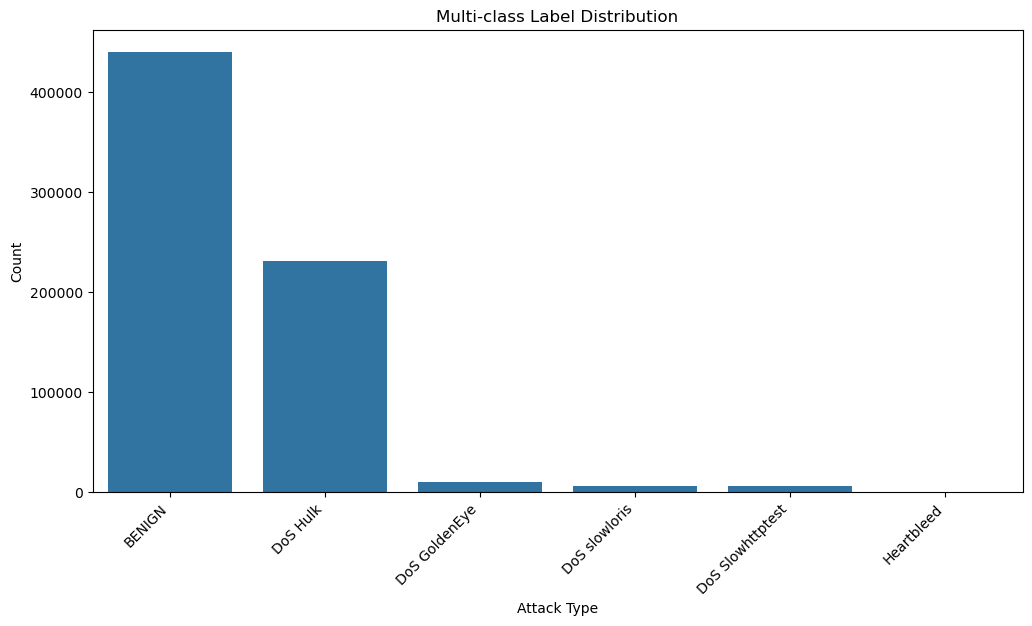

In [5]:

import matplotlib.pyplot as plt
import seaborn as sns

# Binary label distribution
plt.figure(figsize=(6,4))
sns.countplot(x='BinaryLabel', data=cicids_df)
plt.xticks([0,1], ['Normal', 'Attack'])
plt.title('Binary Label Distribution')
plt.ylabel('Count')
plt.show()

# Multi-class label distribution
plt.figure(figsize=(12,6))
# Map encoded labels back to original names
multi_class_counts = cicids_df.groupby('Label')['MultiClassLabel'].count().sort_values(ascending=False)
sns.barplot(x=multi_class_counts.index, y=multi_class_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title('Multi-class Label Distribution')
plt.ylabel('Count')
plt.xlabel('Attack Type')
plt.show()



## Step 4: Normalize Features

Most machine learning models perform better when numeric features are on a similar scale.

* Use **StandardScaler** to standardize all numeric features (mean = 0, std = 1).
* Exclude label columns (`Label`, `BinaryLabel`, `MultiClassLabel`) from scaling.


In [6]:

from sklearn.preprocessing import StandardScaler

# Select numeric feature columns (exclude label columns)
feature_cols = [col for col in cicids_df.columns if col not in ['Label', 'BinaryLabel', 'MultiClassLabel']]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform features
cicids_df[feature_cols] = scaler.fit_transform(cicids_df[feature_cols])

# Preview scaled data
print(cicids_df[feature_cols].head())


   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0         -0.356503      -0.653857          -0.011451               -0.009362   
1         -0.336856      -0.654742           0.001932               -0.005298   
2         -0.355994      -0.654728           0.000594               -0.004282   
3         -0.336856      -0.654398           0.009962                0.001815   
4         -0.355994      -0.654728          -0.000744               -0.004282   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                    -0.089086                    -0.007581   
1                    -0.062154                    -0.007438   
2                     0.421001                    -0.006178   
3                     0.469998                    -0.004612   
4                     0.421001                    -0.006177   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0              -0.376966              -0.176667            

## Step 5: Split Dataset into Train & Test Sets

Before training ML models, we need to divide the dataset into:

* **Training set**: used to fit the model
* **Test set**: used to evaluate model performance

We will perform a **stratified split** to preserve the label distribution for both binary and multi-class labels.


In [7]:

from sklearn.model_selection import train_test_split

# Features
X = cicids_df[feature_cols]

# Binary target
y_binary = cicids_df['BinaryLabel']

# Multi-class target
y_multi = cicids_df['MultiClassLabel']

# Split for binary classification
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.2, stratify=y_binary, random_state=42
)

# Split for multi-class classification
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X, y_multi, test_size=0.2, stratify=y_multi, random_state=42
)

print("Binary train/test sizes:", X_train_bin.shape, X_test_bin.shape)
print("Multi-class train/test sizes:", X_train_multi.shape, X_test_multi.shape)


Binary train/test sizes: (554162, 78) (138541, 78)
Multi-class train/test sizes: (554162, 78) (138541, 78)


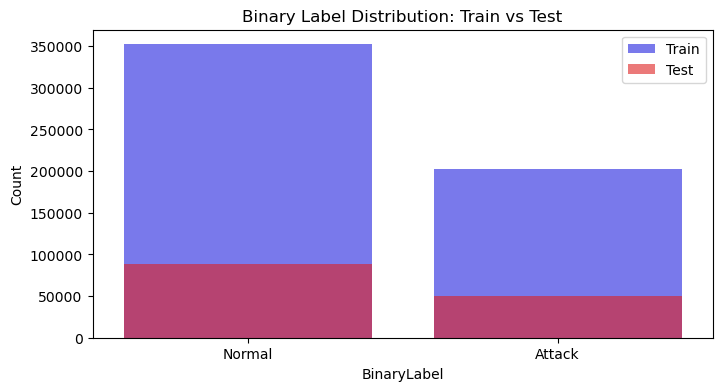

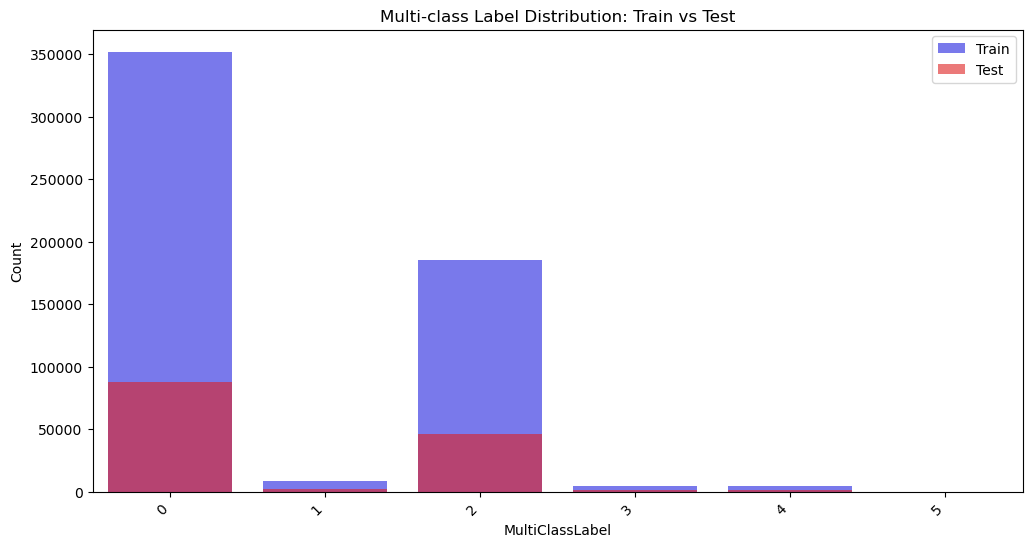

In [8]:

import matplotlib.pyplot as plt
import seaborn as sns

# Binary labels
plt.figure(figsize=(8,4))
train_counts = y_train_bin.value_counts()
test_counts = y_test_bin.value_counts()
sns.barplot(x=train_counts.index, y=train_counts.values, color='blue', alpha=0.6, label='Train')
sns.barplot(x=test_counts.index, y=test_counts.values, color='red', alpha=0.6, label='Test')
plt.xticks([0,1], ['Normal', 'Attack'])
plt.ylabel('Count')
plt.title('Binary Label Distribution: Train vs Test')
plt.legend()
plt.show()

# Multi-class labels
plt.figure(figsize=(12,6))
train_counts_multi = y_train_multi.value_counts().sort_index()
test_counts_multi = y_test_multi.value_counts().sort_index()
sns.barplot(x=train_counts_multi.index, y=train_counts_multi.values, color='blue', alpha=0.6, label='Train')
sns.barplot(x=test_counts_multi.index, y=test_counts_multi.values, color='red', alpha=0.6, label='Test')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Multi-class Label Distribution: Train vs Test')
plt.legend()
plt.show()



## Step 6: Train Multiple ML Models (Binary Classification)

We will train the following models to classify **Normal vs Attack**:

1. **Logistic Regression**
2. **Decision Tree**
3. **Random Forest**
4. **Gradient Boosting**

Each model will be trained on the **training set** and evaluated on the **test set** using:

* Accuracy
* Precision
* Recall
* F1-score
* Confusion matrix


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Dictionary to store models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight='balanced', n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,        # reduced trees for speed
        max_depth=3,             # shallower trees
        subsample=0.8,           # sample 80% of data per tree
        max_features='sqrt',     # random feature subset
        random_state=42
    )
}

# Train and evaluate each model
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_bin, y_train_bin)
    y_pred = model.predict(X_test_bin)
    
    print(f"\n{name} - Classification Report:\n")
    print(classification_report(y_test_bin, y_pred, target_names=['Normal', 'Attack']))
    
    cm = confusion_matrix(y_test_bin, y_pred)
    print(f"{name} - Confusion Matrix:\n", cm)
    print("\n" + "-"*60 + "\n")


Training Logistic Regression...

Logistic Regression - Classification Report:

              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99     88006
      Attack       0.97      0.99      0.98     50535

    accuracy                           0.98    138541
   macro avg       0.98      0.99      0.98    138541
weighted avg       0.99      0.98      0.98    138541

Logistic Regression - Confusion Matrix:
 [[86622  1384]
 [  701 49834]]

------------------------------------------------------------

Training Decision Tree...

Decision Tree - Classification Report:

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     88006
      Attack       1.00      1.00      1.00     50535

    accuracy                           1.00    138541
   macro avg       1.00      1.00      1.00    138541
weighted avg       1.00      1.00      1.00    138541

Decision Tree - Confusion Matrix:
 [[87976    30]
 [   14 50521]]

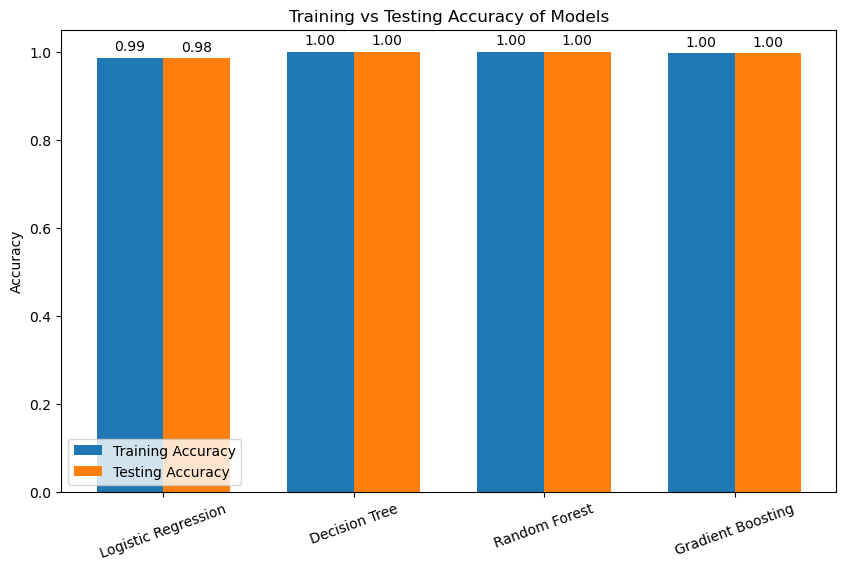

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# Store accuracies
train_accuracies = {}
test_accuracies = {}

# Calculate training & testing accuracy for each model
for name, model in models.items():
    y_train_pred = model.predict(X_train_bin)
    y_test_pred = model.predict(X_test_bin)
    
    train_accuracies[name] = accuracy_score(y_train_bin, y_train_pred)
    test_accuracies[name] = accuracy_score(y_test_bin, y_test_pred)

# Plot accuracies
labels = list(models.keys())
train_vals = [train_accuracies[m] for m in labels]
test_vals = [test_accuracies[m] for m in labels]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,6))
bars1 = plt.bar(x - width/2, train_vals, width, label='Training Accuracy')
bars2 = plt.bar(x + width/2, test_vals, width, label='Testing Accuracy')

# Add accuracy values on top of bars
for bar in bars1 + bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha='center', va='bottom')

plt.xticks(x, labels, rotation=20)
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("Training vs Testing Accuracy of Models")
plt.legend()
plt.show()


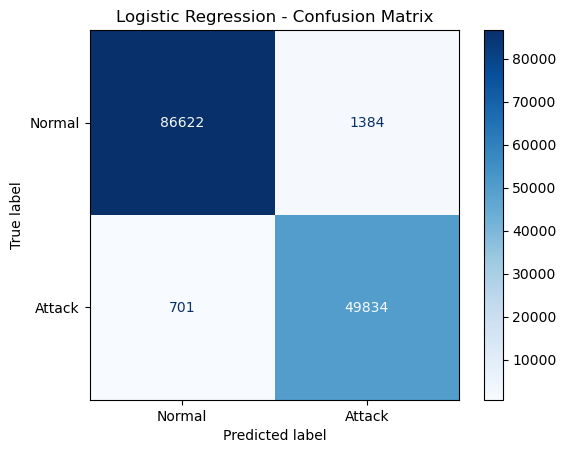

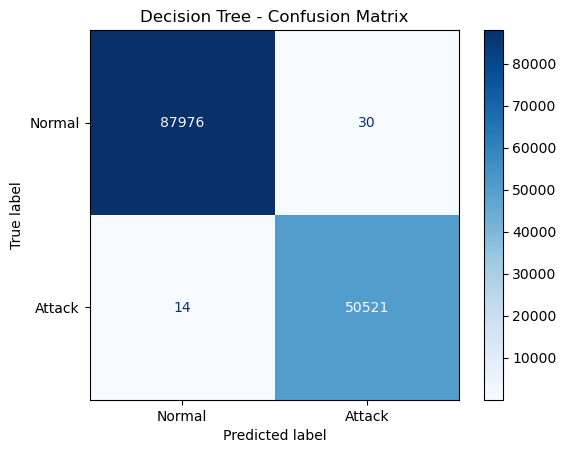

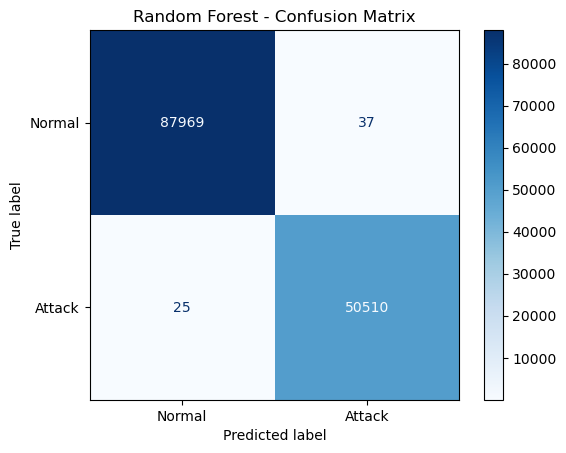

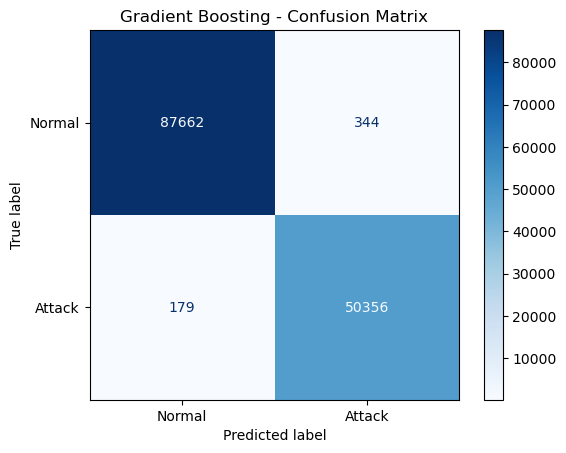

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Plot confusion matrices for each model
for name, model in models.items():
    y_pred = model.predict(X_test_bin)
    
    disp = ConfusionMatrixDisplay.from_estimator(
        model, X_test_bin, y_test_bin,
        display_labels=['Normal', 'Attack'],
        cmap=plt.cm.Blues,
        values_format='d'
    )
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Store metrics for each model
multi_metrics = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-score": []
}

# Train & evaluate models on multi-class data
for name, model in models.items():
    print(f"Training {name} on Multi-Class Data...")
    model.fit(X_train_multi, y_train_multi)
    y_pred = model.predict(X_test_multi)
    
    # Collect metrics
    multi_metrics["Model"].append(name)
    multi_metrics["Accuracy"].append(accuracy_score(y_test_multi, y_pred))
    multi_metrics["Precision"].append(precision_score(y_test_multi, y_pred, average='weighted', zero_division=0))
    multi_metrics["Recall"].append(recall_score(y_test_multi, y_pred, average='weighted', zero_division=0))
    multi_metrics["F1-score"].append(f1_score(y_test_multi, y_pred, average='weighted', zero_division=0))

# Convert to DataFrame
multi_metrics_df = pd.DataFrame(multi_metrics)
print(multi_metrics_df)


Training Logistic Regression on Multi-Class Data...
Training Decision Tree on Multi-Class Data...
Training Random Forest on Multi-Class Data...
Training Gradient Boosting on Multi-Class Data...
                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.978873   0.983254  0.978873  0.980073
1        Decision Tree  0.999502   0.999502  0.999502  0.999502
2        Random Forest  0.999502   0.999502  0.999502  0.999502
3    Gradient Boosting  0.998297   0.998298  0.998297  0.998296


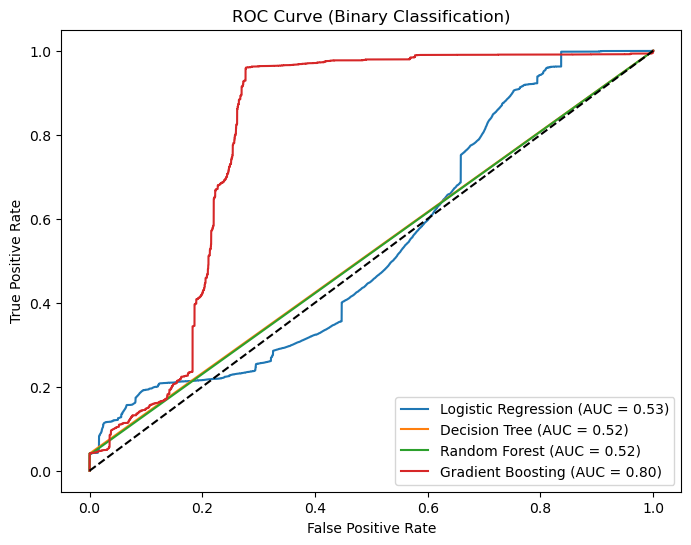

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models.items():
    # Predict probabilities
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_bin)[:,1]   # probability for "Attack"
    else:
        y_score = model.decision_function(X_test_bin)    # for models without predict_proba
    
    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test_bin, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Random guess line
plt.plot([0,1], [0,1], 'k--')

plt.title("ROC Curve (Binary Classification)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()
